# 09 - Brayton Gas-Turbine Cycle

The **Brayton cycle** is the thermodynamic backbone of gas-turbine engines for
power generation and jet propulsion. The air-standard idealisation comprises
four processes:

1. **Isentropic compression** (compressor): $P_1 \to P_2 = r_p P_1$
2. **Isobaric heat addition** (combustor): $T_2 \to T_3$
3. **Isentropic expansion** (turbine): $P_3 \to P_4 = P_3 / r_p$
4. **Isobaric heat rejection** (exhaust)

Textbook analysis assumes constant $C_p$ and $\gamma = C_p/C_v$, giving the
familiar efficiency $\eta = 1 - r_p^{(1-\gamma)/\gamma}$. Here we use
`pyglenn`'s **real** $C_p(T)$ and $S^\circ(T)$ — the working fluid is a
real-gas mixture of O₂ and N₂ (air) — and solve the isentropic
$S(T_2) = S(T_1)$ condition numerically.

The thermal efficiency follows directly from the enthalpy values at each state:

$$\eta = 1 - \frac{H_4 - H_1}{H_3 - H_2}.$$

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Universal gas constant R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from scipy.optimize import brentq

## 1. Air as the working fluid

We model dry air as the mixture $1\ \mathrm{O_2} + 3.76\ \mathrm{N_2}$.
Single-species functions for enthalpy and entropy of the mixture follow.

In [3]:
AIR = {"O2": 1.0, "N2": 3.76}
R_UNIV = R  # J/(mol·K) — universal gas constant

def air_enthalpy(calc, T):
    """Total standardized enthalpy of 1 mol air at T, in J."""
    return sum(n * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["h_relative"]
               for name, n in AIR.items())

def air_entropy_std(calc, T):
    """Standard-state (P=1 bar) entropy of 1 mol air at T, in J/K."""
    return sum(n * calc.calculate_properties(calc.get_available_species(name, exact_match=True)[0]["id"], T)["s"]
               for name, n in AIR.items())

# Total moles in the mixture per mol of "air"
AIR_MOLES = sum(AIR.values())  # = 4.76


## 2. Isentropic relation with real $C_p(T)$

For an ideal gas the molar entropy at $(T,P)$ is

$$s(T,P) = s^\circ(T) - R \ln\frac{P}{P_0}.$$

For an **isentropic** process ($s_2 = s_1$) between pressures $P_1$ and $P_2$,
the pressure terms give $s^\circ(T_2) - s^\circ(T_1) = R\ln(P_2/P_1)$. We solve

$$f(T) = s^\circ(T) - s^\circ(T_1) - R \ln\frac{P_2}{P_1} = 0$$

for $T_2$ with a robust bracketed root-finder, accounting for the total moles
in the air mixture.

In [4]:
def isentropic_T(calc, T1, P_ratio):
    """Temperature after isentropic compression/expansion (P2/P1 = P_ratio).

    Returns T2 [K] such that s°(T2) - s°(T1) = R_air * ln(P2/P1),
    where R_air = R / M_air = R per mole of mixture times total moles.
    """
    s1 = air_entropy_std(calc, T1)
    R_air = R_UNIV * AIR_MOLES  # J/K per mol of air mixture
    target = s1 + R_air * np.log(P_ratio)

    def f(T):
        return air_entropy_std(calc, T) - target

    # Search bracket: entropy grows with T, so compression (P_ratio>1)
    # pushes T2 > T1; expansion (P_ratio<1) pushes T2 < T1.
    if P_ratio > 1:
        lo, hi = T1, T1 * (P_ratio ** 0.4 + 1)
    else:
        lo, hi = T1 * P_ratio ** 0.4, T1

    # Expand bracket if needed
    while f(lo) * f(hi) > 0:
        if P_ratio > 1:
            hi *= 1.3
        else:
            lo *= 0.7
        if hi > 6000 or lo < 50:
            raise RuntimeError(f"Could not bracket T2 for P_ratio={P_ratio}")

    return brentq(f, lo, hi)


## 3. Building the Brayton cycle

We set the cycle parameters:
- Inlet: $T_1 = 300\ \mathrm{K}$, $P_1 = 1\ \mathrm{bar}$
- Pressure ratio: $r_p = P_2/P_1 = 10$
- Turbine inlet temperature (TIT): $T_3 = 1400\ \mathrm{K}$

The four states are computed with real $C_p(T)$ via the isentropic solver.

In [5]:
def brayton_states(calc, T1, T3, rp):
    """Return dict of (T, h_per_kg_air) for the four Brayton states.

    h values are in kJ per kg of air (not per mole of mixture).
    """
    # Molecular weight of the air mixture (mole-weighted average)
    M_O2 = 31.9988   # g/mol
    M_N2 = 28.0134   # g/mol
    M_air = (AIR["O2"] * M_O2 + AIR["N2"] * M_N2) / AIR_MOLES  # g/mol

    T2 = isentropic_T(calc, T1, rp)          # compressor outlet
    T4 = isentropic_T(calc, T3, 1.0 / rp)    # turbine outlet

    def h_kJ_kg(T):
        return air_enthalpy(calc, T) / (M_air * 1e-3) / 1000  # kJ/kg

    return {
        "1 (compressor inlet)":  (T1, h_kJ_kg(T1)),
        "2 (compressor outlet)": (T2, h_kJ_kg(T2)),
        "3 (turbine inlet)":     (T3, h_kJ_kg(T3)),
        "4 (turbine outlet)":    (T4, h_kJ_kg(T4)),
    }

with ThermochemicalCalculator() as calc:
    states = brayton_states(calc, T1=300.0, T3=1400.0, rp=10)

print(f"{'State':<26s} {'T [K]':>8s} {'h [kJ/kg]':>12s}")
print("-" * 46)
for label, (T, h) in states.items():
    print(f"{label:<26s} {T:8.1f} {h:12.2f}")


State                         T [K]    h [kJ/kg]
----------------------------------------------
1 (compressor inlet)          300.0         8.91
2 (compressor outlet)         573.1      1344.35
3 (turbine inlet)            1400.0      5834.55
4 (turbine outlet)            789.3      2453.76


## 4. Thermal efficiency

$$\eta_\mathrm{th} = \frac{w_\mathrm{net}}{q_\mathrm{in}}
  = \frac{(h_3 - h_4) - (h_2 - h_1)}{h_3 - h_2}
  = 1 - \frac{h_4 - h_1}{h_3 - h_2}.$$

We compare the real-gas result with the constant-$\gamma$ textbook formula
($\gamma \approx 1.4$ for diatomic air).

In [6]:
T1, h1 = states["1 (compressor inlet)"]
T2, h2 = states["2 (compressor outlet)"]
T3, h3 = states["3 (turbine inlet)"]
T4, h4 = states["4 (turbine outlet)"]

w_comp = h2 - h1          # compressor work [kJ/kg]
w_turb = h3 - h4          # turbine work [kJ/kg]
q_in   = h3 - h2          # heat added [kJ/kg]
eta_real = (w_turb - w_comp) / q_in

# Cold air-standard (constant gamma = 1.4)
gamma = 1.4
rp = 10
eta_cold = 1 - rp ** ((1 - gamma) / gamma)

print(f"Real-gas Brayton efficiency  : {eta_real:.4f} ({eta_real*100:.1f}%)")
print(f"Cold air-standard (gamma=1.4): {eta_cold:.4f} ({eta_cold*100:.1f}%)")
print(f"Turbine work : {w_turb:.1f} kJ/kg")
print(f"Compressor work: {w_comp:.1f} kJ/kg")
print(f"Net work      : {w_turb - w_comp:.1f} kJ/kg")


Real-gas Brayton efficiency  : 0.4555 (45.6%)
Cold air-standard (gamma=1.4): 0.4821 (48.2%)
Turbine work : 3380.8 kJ/kg
Compressor work: 1335.4 kJ/kg
Net work      : 2045.3 kJ/kg


## 5. T–s diagram (qualitative)

We sketch the four states on temperature–entropy axes, using the standard
entropy of the air mixture at each state pressure.

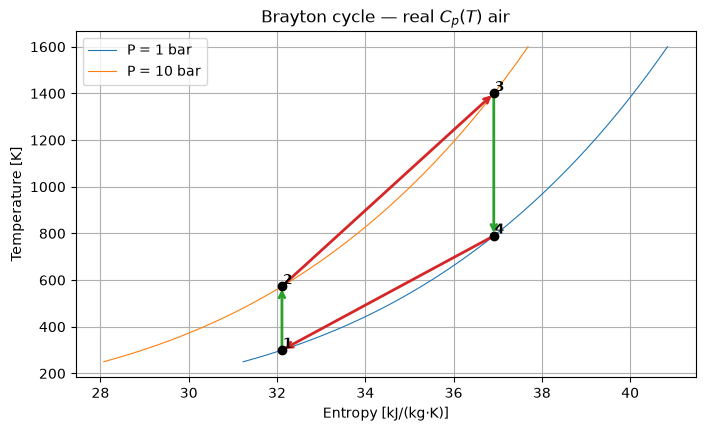

In [7]:
def air_s_at_P(calc, T, P_bar):
    """Entropy of air mixture at (T, P), in kJ/(kg·K)."""
    s_std = air_entropy_std(calc, T)           # J/K per mol mixture
    R_air = R_UNIV * AIR_MOLES                  # J/K per mol mixture
    s_p = s_std - R_air * np.log(P_bar / 1.0)  # J/K per mol mixture
    M_air = (AIR["O2"] * 31.9988 + AIR["N2"] * 28.0134) / AIR_MOLES
    return s_p / (M_air * 1e-3) / 1000          # kJ/(kg·K)

rp = 10
T1_val, T3_val = 300.0, 1400.0

with ThermochemicalCalculator() as calc:
    T2_val = isentropic_T(calc, T1_val, rp)
    T4_val = isentropic_T(calc, T3_val, 1.0 / rp)

    # Isobars at P=1 bar and P=10 bar
    T_range = np.linspace(250, 1600, 100)
    s_low   = np.array([air_s_at_P(calc, T, 1)  for T in T_range])
    s_high  = np.array([air_s_at_P(calc, T, 10) for T in T_range])

    # The four states
    s1 = air_s_at_P(calc, T1_val, 1)
    s2 = air_s_at_P(calc, T2_val, 10)
    s3 = air_s_at_P(calc, T3_val, 10)
    s4 = air_s_at_P(calc, T4_val, 1)

fig, ax = plt.subplots()
ax.plot(s_low,  T_range, "C0", lw=0.8, label="P = 1 bar")
ax.plot(s_high, T_range, "C1", lw=0.8, label="P = 10 bar")
# Process arrows
ax.annotate("", xy=(s2, T2_val), xytext=(s1, T1_val),
            arrowprops=dict(arrowstyle="->", color="C2", lw=2))
ax.annotate("", xy=(s3, T3_val), xytext=(s2, T2_val),
            arrowprops=dict(arrowstyle="->", color="C3", lw=2))
ax.annotate("", xy=(s4, T4_val), xytext=(s3, T3_val),
            arrowprops=dict(arrowstyle="->", color="C2", lw=2))
ax.annotate("", xy=(s1, T1_val), xytext=(s4, T4_val),
            arrowprops=dict(arrowstyle="->", color="C3", lw=2))
ax.scatter([s1, s2, s3, s4], [T1_val, T2_val, T3_val, T4_val],
           color="black", zorder=5)
for i, (s, T, lbl) in enumerate([(s1, T1_val, "1"), (s2, T2_val, "2"),
                                  (s3, T3_val, "3"), (s4, T4_val, "4")]):
    ax.text(s + 0.02, T + 10, lbl, fontweight="bold")
ax.set_xlabel("Entropy [kJ/(kg·K)]")
ax.set_ylabel("Temperature [K]")
ax.set_title("Brayton cycle — real $C_p(T)$ air")
ax.legend()
plt.show()


## 6. Efficiency vs. pressure ratio: real vs. cold air-standard

The cold air-standard formula $\eta = 1 - r_p^{(1-\gamma)/\gamma}$ predicts
monotonically increasing efficiency. With real $C_p(T)$, the efficiency curve
is similar in shape but shifted because $\gamma(T)$ decreases as temperature
rises (vibrational modes unlock), making the compressor "stiffer" and the
turbine less effective at higher pressure ratios than the cold-air
approximation suggests.

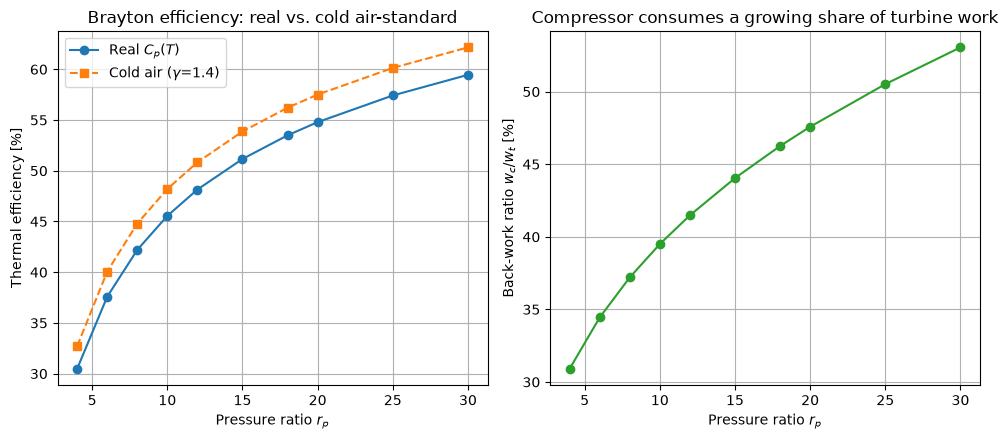

In [8]:
rp_range = np.array([4, 6, 8, 10, 12, 15, 18, 20, 25, 30])
eta_real_list = []
eta_cold_list = []
backwork_list = []

with ThermochemicalCalculator() as calc:
    for rp in rp_range:
        st = brayton_states(calc, T1=300.0, T3=1400.0, rp=rp)
        _, h1 = st["1 (compressor inlet)"]
        _, h2 = st["2 (compressor outlet)"]
        _, h3 = st["3 (turbine inlet)"]
        _, h4 = st["4 (turbine outlet)"]
        w_comp = h2 - h1
        w_turb = h3 - h4
        q_in   = h3 - h2
        eta_real_list.append((w_turb - w_comp) / q_in * 100)
        eta_cold_list.append((1 - rp ** ((1 - 1.4) / 1.4)) * 100)
        backwork_list.append(w_comp / w_turb * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

ax1.plot(rp_range, eta_real_list, "o-", label="Real $C_p(T)$")
ax1.plot(rp_range, eta_cold_list, "s--", label=r"Cold air ($\gamma$=1.4)")
ax1.set_xlabel("Pressure ratio $r_p$")
ax1.set_ylabel("Thermal efficiency [%]")
ax1.set_title("Brayton efficiency: real vs. cold air-standard")
ax1.legend()

ax2.plot(rp_range, backwork_list, "o-", color="C2")
ax2.set_xlabel("Pressure ratio $r_p$")
ax2.set_ylabel("Back-work ratio $w_c / w_t$ [%]")
ax2.set_title("Compressor consumes a growing share of turbine work")

plt.tight_layout()
plt.show()


## Summary

- Real $C_p(T)$ from `pyglenn` enables accurate Brayton-cycle analysis without
  assuming constant $\gamma$.
- The isentropic condition $s^\circ(T_2) = s^\circ(T_1) + R\ln(P_2/P_1)$ is
  solved numerically for each process.
- The real efficiency curve is close to but distinct from the cold-air ideal;
  the difference grows at higher pressure ratios where $\gamma(T)$ deviates
  from 1.4.
- The back-work ratio (compressor work / turbine work) rises with $r_p$,
  limiting practical pressure ratios for single-shaft engines.

**Next:** notebook 10 shows how to use `pyglenn` as a high-performance property
provider for CFD and chemical kinetics codes.